In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

In [2]:
#Load data
df = pd.read_csv('weather_data.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)
df

,temperature,humidity,precipitation,wind_direction,wind speed,weather observation
datetime,,,,,,
2019-01-01 00:00:00,26.8,67.0,NaN,350,11.0,NaN
2019-01-01 01:00:00,26.8,62.0,NaN,360,15.0,NaN
2019-01-01 02:00:00,26.8,62.0,NaN,10,13.0,NaN
2019-01-01 03:00:00,26.8,67.0,NaN,20,11.0,NaN
2019-01-01 04:00:00,26.8,71.0,NaN,40,11.0,NaN
...,...,...,...,...,...,...
2024-11-20 19:00:00,24.0,61.0,NaN,90,7.0,NaN
2024-11-20 20:00:00,24.0,65.0,NaN,low winds from changing directions,4.0,NaN
2024-11-20 21:00:00,23.0,69.0,NaN,60,9.0,NaN


In [3]:
# df['date'] = df['datetime'].dt.date

df['temperature'] = df['temperature'].interpolate(method='time')
df['temperature'] = df['temperature'].ffill().bfill()  # Fill remaining NaNs

df

,temperature,humidity,precipitation,wind_direction,wind speed,weather observation
datetime,,,,,,
2019-01-01 00:00:00,26.8,67.0,NaN,350,11.0,NaN
2019-01-01 01:00:00,26.8,62.0,NaN,360,15.0,NaN
2019-01-01 02:00:00,26.8,62.0,NaN,10,13.0,NaN
2019-01-01 03:00:00,26.8,67.0,NaN,20,11.0,NaN
2019-01-01 04:00:00,26.8,71.0,NaN,40,11.0,NaN
...,...,...,...,...,...,...
2024-11-20 19:00:00,24.0,61.0,NaN,90,7.0,NaN
2024-11-20 20:00:00,24.0,65.0,NaN,low winds from changing directions,4.0,NaN
2024-11-20 21:00:00,23.0,69.0,NaN,60,9.0,NaN


In [4]:
temp = df['temperature'].values.reshape(-1, 1)

In [5]:
#Normalize data
scaler = MinMaxScaler(feature_range=(0, 1))
temp = scaler.fit_transform(temp)

In [6]:
#Sequence for training LSTM
def create_sequnces(data, lookback=24):
    X, Y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i + lookback, 0])
        Y.append(data[i + lookback,0])

    return np.array(X), np.array(Y)
lookback = 24
X, Y = create_sequnces(temp, lookback)

# Reshape for LSTM input (samples, time steps, features)
X.reshape(X.shape[0], X.shape[1], 1)

array([[[0.6       ],
        [0.6       ],
        [0.6       ],
        ...,
        [0.6       ],
        [0.6       ],
        [0.6       ]],

       [[0.6       ],
        [0.6       ],
        [0.6       ],
        ...,
        [0.6       ],
        [0.6       ],
        [0.6       ]],

       [[0.6       ],
        [0.6       ],
        [0.6       ],
        ...,
        [0.6       ],
        [0.6       ],
        [0.6       ]],

       ...,

       [[0.54545455],
        [0.54545455],
        [0.54545455],
        ...,
        [0.54545455],
        [0.51515152],
        [0.51515152]],

       [[0.54545455],
        [0.54545455],
        [0.42424242],
        ...,
        [0.51515152],
        [0.51515152],
        [0.48484848]],

       [[0.54545455],
        [0.42424242],
        [0.39393939],
        ...,
        [0.51515152],
        [0.48484848],
        [0.45454545]]])

In [7]:
model = Sequential()
#Addinf the first LSTM layer and some Dropout regularisation
model.add(Input(shape=(X.shape[1], 1)))
model.add(LSTM(units=50, return_sequences = True))
model.add(Dropout(0.2))

model.add(LSTM(units=50, return_sequences = True))
model.add(Dropout(0.2))

model.add(LSTM(units=50, return_sequences = True))
model.add(Dropout(0.2))

model.add(LSTM(units=50))
model.add(Dropout(0.2))

#Output layer
model.add(Dense(units=1))

model.compile(optimizer='adam', loss='mse')

In [8]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 24, 50)            10400     
                                                                 
 dropout (Dropout)           (None, 24, 50)            0         
                                                                 
 lstm_1 (LSTM)               (None, 24, 50)            20200     
                                                                 
 dropout_1 (Dropout)         (None, 24, 50)            0         
                                                                 
 lstm_2 (LSTM)               (None, 24, 50)            20200     
                                                                 
 dropout_2 (Dropout)         (None, 24, 50)            0         
                                                                 
 lstm_3 (LSTM)               (None, 50)                2

In [9]:
train_size = int(len(X) * 0.8)
val_size = int(-100)
X_train, X_val, X_test = X[:train_size], X[train_size: val_size], X[val_size:]
Y_train, Y_val, Y_test = Y[:train_size], Y[train_size: val_size], Y[val_size:]


In [ ]:
# Create a callback that saves the model's weights
cp_callback = tf.keras.callbacks.ModelCheckpoint(filepath='temp_model.weights.h5',
                                                 save_weights_only=True,
                                                 save_best_only=True,
                                                 verbose=1)

history = model.fit(X_train, Y_train,
         epochs=40,
         batch_size=32,
         validation_data=(X_val, Y_val),
         callbacks=[cp_callback]
        )

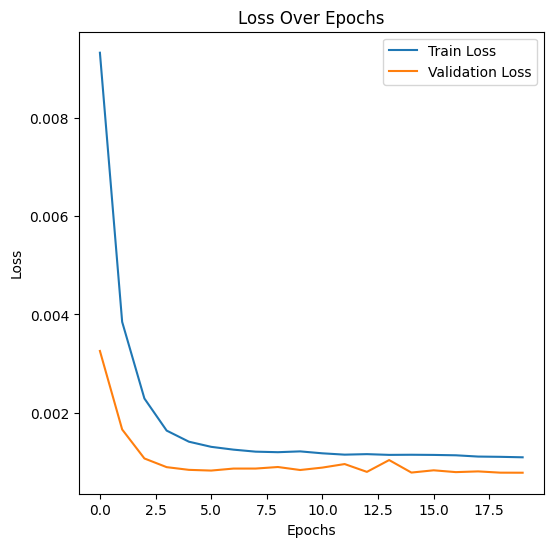

In [15]:
def plot_loss(history):
    # Accuracy plot
    plt.figure(figsize=(6, 6))

    # Loss plot
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.title('Loss Over Epochs')

    plt.show()

plot_loss(history)

In [16]:
model.save('temp_model.keras')

In [17]:
# Predictions
y_pred = model.predict(X_test)

# Inverse scaling to interpret predictions
y_test_inv = scaler.inverse_transform(Y_test.reshape(-1, 1))
y_pred_inv = scaler.inverse_transform(y_pred)

# Calculate RMSE
mse = mean_squared_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mse)
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 105ms/step
MSE: 0.7894470910269226
RMSE: 0.8885083516922745


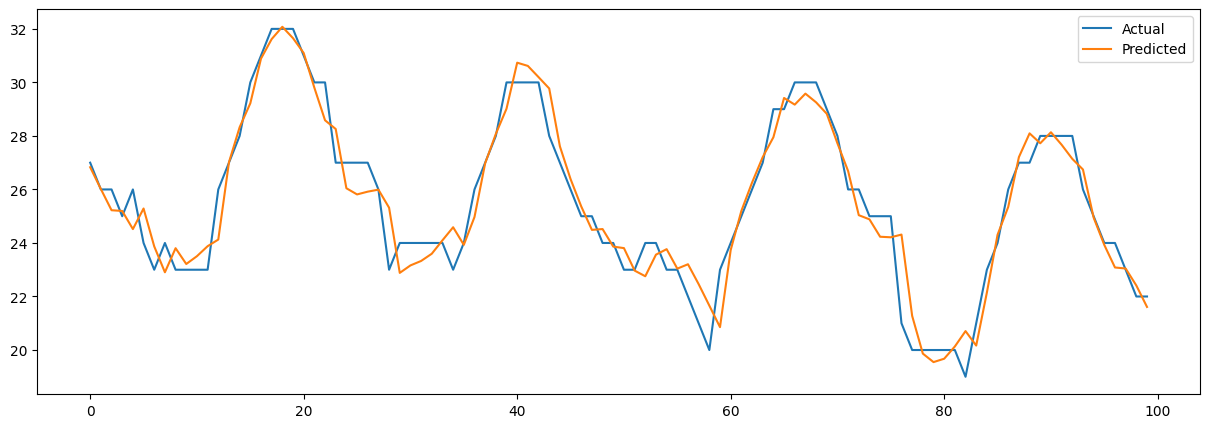

In [18]:
#PLot Actual vs Predicted
plt.figure(figsize=(15, 5))
plt.plot(y_test_inv, label='Actual')
plt.plot(y_pred_inv, label='Predicted')
plt.legend()
plt.show()

In [19]:
humid = df['humidity'].values.reshape(-1, 1)
humid = scaler.fit_transform(humid)

In [20]:
lookback = 10
humX, humY = create_sequnces(humid, lookback)
humX.reshape(humX.shape[0], humX.shape[1], 1)

array([[[0.60714286],
        [0.54761905],
        [0.54761905],
        ...,
        [0.54761905],
        [0.5952381 ],
        [0.54761905]],

       [[0.54761905],
        [0.54761905],
        [0.60714286],
        ...,
        [0.5952381 ],
        [0.54761905],
        [0.5952381 ]],

       [[0.54761905],
        [0.60714286],
        [0.6547619 ],
        ...,
        [0.54761905],
        [0.5952381 ],
        [0.54761905]],

       ...,

       [[0.38095238],
        [0.38095238],
        [0.3452381 ],
        ...,
        [0.45238095],
        [0.53571429],
        [0.58333333]],

       [[0.38095238],
        [0.3452381 ],
        [0.3452381 ],
        ...,
        [0.53571429],
        [0.58333333],
        [0.63095238]],

       [[0.3452381 ],
        [0.3452381 ],
        [0.3452381 ],
        ...,
        [0.58333333],
        [0.63095238],
        [0.67857143]]])

In [21]:
humX_train, humX_val, humX_test = humX[:train_size], humX[train_size:val_size], humX[val_size:]
humY_train, humY_val, humY_test = humY[:train_size], humY[train_size:val_size], humY[val_size:]

In [22]:
humid_model = Sequential()
#Addinf the first LSTM layer and some Dropout regularisation
humid_model.add(Input(shape=(humX.shape[1], 1)))
humid_model.add(LSTM(units=50, return_sequences = True))
humid_model.add(Dropout(0.2))

humid_model.add(LSTM(units=50))
humid_model.add(Dropout(0.2))

#Output layer
humid_model.add(Dense(units=1))

humid_model.compile(optimizer='adam', loss='mse')

In [23]:
humid_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 10, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 10, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
# Create a callback that saves the model's weights
checkpoint = tf.keras.callbacks.ModelCheckpoint(filepath='humid_model.weights.h5',
                                                 save_weights_only=True,
                                                 save_best_only=True,
                                                 verbose=1)

history = humid_model.fit(humX_train, humY_train,
         epochs=40,
         batch_size=32,
         validation_data=(humX_val, humY_val),
         callbacks=[checkpoint]
        )

Epoch 1/20
1282/1290 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0370
Epoch 1: val_loss improved from inf to 0.00551, saving model to humid_model.weights.h5
1290/1290 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 0.0369 - val_loss: 0.0055
Epoch 2/20
1283/1290 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0088
Epoch 2: val_loss improved from 0.00551 to 0.00501, saving model to humid_model.weights.h5
1290/1290 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 0.0088 - val_loss: 0.0050
Epoch 3/20
1286/1290 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0072
Epoch 3: val_loss improved from 0.00501 to 0.00486, saving model to humid_model.weights.h5
1290/1290 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 0.0072 - val_loss: 0.0049
Epoch 4/20
1282/1290 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0067
Epoch 4: val_loss improved from 0.00486 to 0.00429, saving model to humid_model.weights.h5
1290/1290 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 0.0067 - val_loss: 0.0043
Epoch 5/20
1282/1290 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step -

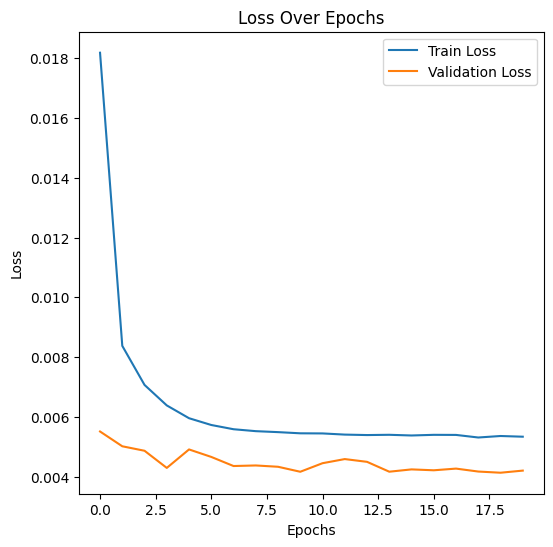

In [26]:
plot_loss(history)

In [27]:
humid_model.save('humid_model.keras')

In [28]:
# Predictions

y_pred = model.predict(humX_test)

# Inverse scaling to interpret predictions
y_test_inv = scaler.inverse_transform(humY_test.reshape(-1, 1))
y_pred_inv = scaler.inverse_transform(y_pred)

# Calculate RMSE
mse = mean_squared_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mse)
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step  
MSE: 35.379614547441015
RMSE: 5.948076541827704


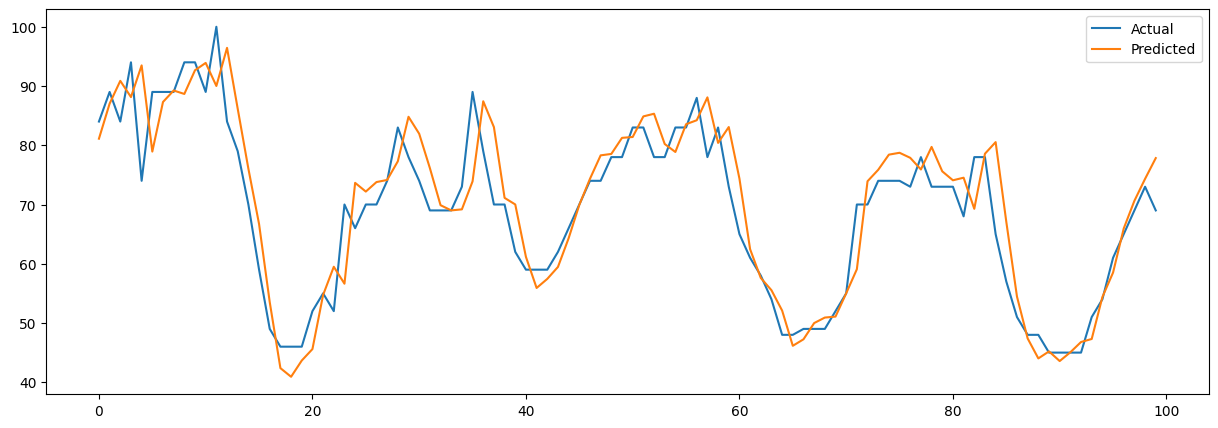

In [29]:
#PLot Actual vs Predicted
plt.figure(figsize=(15, 5))
plt.plot(y_test_inv, label='Actual')
plt.plot(y_pred_inv, label='Predicted')
plt.legend()
plt.show()